Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

[OPTIMIZER] epoch_start=0 global_step=0 wrapped=AcceleratedOptimizer base=AdamW lr=0.0 id=128665991192816 hyperparams={'lr': 0.0, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 3e-05}
[OPTIMIZER_GROUP]   group[0] {'lr': 0.0, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 3e-05}
[SCHEDULER]   scheduler_last_lr=[0.0]
[PARAMS]   params_total=129,137,667 params_trainable=129,137,667


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro,Mse,Sse
1,1.730100,0.471505,0.816667,0.815334,0.817262,0.816667,0.088758,26.627510
2,0.705600,0.353205,0.860000,0.860242,0.860566,0.860000,0.065011,19.503209
3,0.469200,0.330328,0.873333,0.872949,0.872766,0.873333,0.061281,18.384198
4,0.280900,0.327974,0.876667,0.876798,0.876958,0.876667,0.059390,17.817050


[TRAINING_PERFORMANCE] epoch=1.0 tokens=0 time=27.77s tok/s=0.0 ex/s=0.00 peak_mem=2.98GiB lr=2.39e-05
[EVALUATION_PERFORMANCE] tokens=81920 time=0.55s tok/s=147710.1 ex/s=1153.99
[EVALUATION_PERFORMANCE] accuracy=0.8167 cost=$0.02 accuracy_per_$=50.26
[OPTIMIZER] epoch_start=1.0 global_step=75 wrapped=AcceleratedOptimizer base=AdamW lr=2.3936170212765956e-05 id=128665991192816 hyperparams={'lr': 2.3936170212765956e-05, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 3e-05}
[OPTIMIZER_GROUP]   group[0] {'lr': 2.3936170212765956e-05, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 3e-05}
[SCHEDULER]   scheduler_last_lr=[2.3936170212765956e-05]
[PARAMS] 

[EVALUATION_PERFORMANCE] tokens=81920 time=0.74s tok/s=110674.5 ex/s=864.64
[EVALUATION_PERFORMANCE] accuracy=0.8833 cost=$0.10 accuracy_per_$=8.61

### STATE-SPACES/MAMBA-130M-HF EVALUATION METRICS ###
{'epoch': 4.0,
 'eval_accuracy': 0.8833333333333333,
 'eval_f1_macro': 0.8834717813646699,
 'eval_loss': 0.3522745370864868,
 'eval_mse': 0.06184474058209431,
 'eval_precision_macro': 0.8842309028473698,
 'eval_recall_macro': 0.8833333333333333,
 'eval_runtime': 0.816,
 'eval_samples_per_second': 367.641,
 'eval_sse': 18.553422174628295,
 'eval_steps_per_second': 6.127}


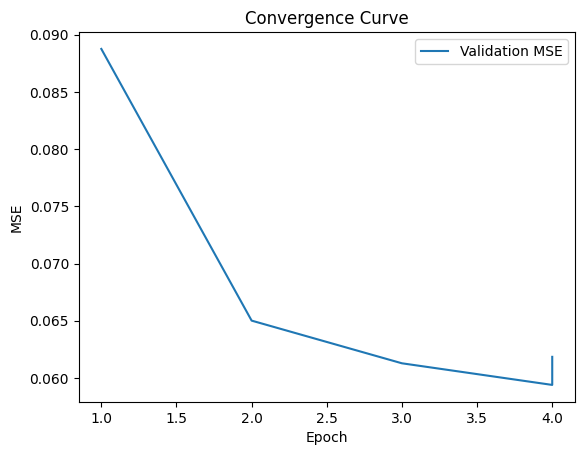

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2400 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

In [1]:
# A State Space Model Approach to Cross-Lingual Sentiment Analysis of Filipino Texts 


import os
import pandas as pd
import pprint

from pathlib import Path
from transformers import pipeline

from src.config import *
from src.metrics import evaluate_pipe
from src import (
    context,
    helper,
    sentiment, 
    utility, 
)

os.environ["HF_DATASETS_DISABLE_CACHING"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
helper.list_config()

if App.HAS_GPU:
    os.environ["MAMBA_USE_MAMBAPY"] = Mamba.FORCE_CUDA
    os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

if App.ACTION == "TRAIN":
    mamba_context = context.setup_pipeline(Mamba, require_translation = False)
    mamba_trainer = sentiment.train(mamba_context)

